In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 베이스 파일 로드 (전처리 완료된 주문-아이템 단위 데이터)
df = pd.read_csv('../../../Funnel_Cohort_NG/data/olist_order_item_level.csv')

# 배송 완료된 주문만 필터링
# - 미완료 주문은 실제 배송일이 없어 지연 여부 판단 불가
df = df[df['order_status'] == 'delivered'].copy()

# 날짜 컬럼 datetime 변환
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])

# 실제 배송일 - 예정일 차이 (음수 = 조기 도착, 양수 = 지연)
df['days_diff'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days

# 배송 유형별 평균 리뷰 점수
early_review = df[df['days_diff'] < 0]['review_score_mean'].mean()
normal_review = df[df['days_diff'] == 0]['review_score_mean'].mean()
late_review = df[df['is_late'] == True]['review_score_mean'].mean()

print(f"=== 현재 베이스라인 ===")
print(f"분석 대상 주문 수: {len(df):,}건")
print(f"현재 지연율: {df['is_late'].mean()*100:.1f}%")
print(f"현재 평균 리뷰: {df['review_score_mean'].mean():.3f}")
print()
print(f"=== 배송 유형별 평균 리뷰 ===")
print(f"조기 도착: {early_review:.3f}점 ({(df['days_diff'] < 0).sum():,}건)")
print(f"정시 배송: {normal_review:.3f}점 ({(df['days_diff'] == 0).sum():,}건)")
print(f"지연 배송: {late_review:.3f}점 ({df['is_late'].sum():,}건)")

=== 현재 베이스라인 ===
분석 대상 주문 수: 110,197건
현재 지연율: 7.9%
현재 평균 리뷰: 4.082

=== 배송 유형별 평균 리뷰 ===
조기 도착: 4.212점 (101,475건)
정시 배송: 3.987점 (1,450건)
지연 배송: 2.549점 (8,714건)


In [5]:
# A/B 테스트 시뮬레이션
# 가설: 예정일을 X일 늘리면 현재 지연 주문 중 일부가 조기 도착으로 전환됨
# 전환된 주문의 리뷰는 조기 도착 평균(4.212점)으로 개선된다고 가정
# 한계: 예정일 연장 시 구매 포기 고객 증가 효과는 반영 불가

results = []

for extra_days in range(0, 8):
    # 예정일을 extra_days만큼 늘렸을 때 지연 여부 재계산
    new_estimated = df['order_estimated_delivery_date'] + pd.Timedelta(days=extra_days)
    new_is_late = df['order_delivered_customer_date'] > new_estimated
    
    # 지연→정시/조기 전환된 주문 수
    converted = (df['is_late'] == True) & (new_is_late == False)
    converted_count = converted.sum()
    
    # 예상 평균 리뷰
    # 전환된 주문은 조기 도착 평균 리뷰(4.212)로 개선된다고 가정
    total = len(df)
    new_late_count = new_is_late.sum()
    new_normal_count = total - new_late_count
    
    expected_review = (
        (early_review * new_normal_count + late_review * new_late_count) / total
    )
    
    results.append({
        '추가일수': extra_days,
        '지연율': round(new_is_late.mean() * 100, 2),
        '전환건수': converted_count,
        '예상평균리뷰': round(expected_review, 3)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string())

   추가일수   지연율  전환건수  예상평균리뷰
0     0  7.91     0   4.080
1     1  6.59  1450   4.102
2     2  5.74  2388   4.116
3     3  5.19  2991   4.125
4     4  4.68  3560   4.134
5     5  4.23  4055   4.141
6     6  3.77  4562   4.149
7     7  3.36  5014   4.156


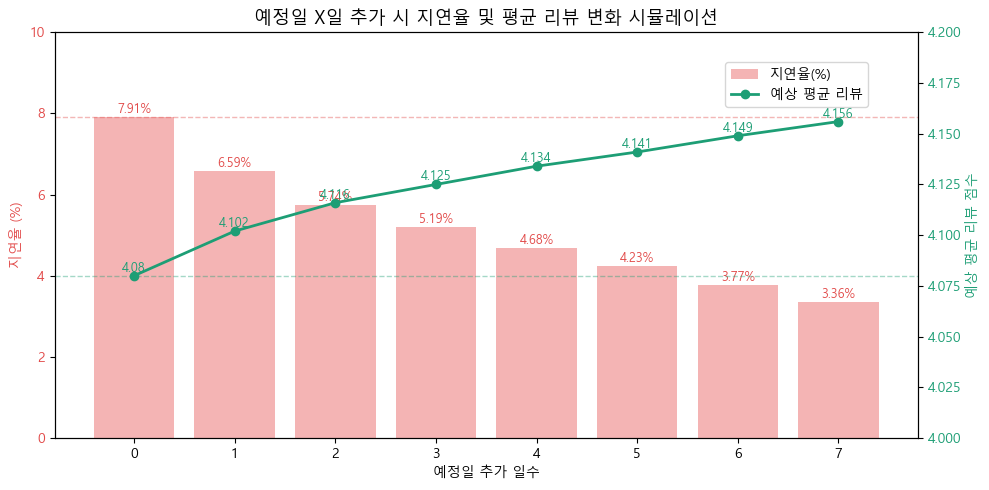

In [6]:
fig, ax1 = plt.subplots(figsize=(10, 5))

x = results_df['추가일수']

# 지연율 막대
ax1.bar(x, results_df['지연율'], color='#F09595', alpha=0.7, label='지연율(%)')
ax1.set_xlabel('예정일 추가 일수')
ax1.set_ylabel('지연율 (%)', color='#E24B4A')
ax1.tick_params(axis='y', labelcolor='#E24B4A')
ax1.set_ylim(0, 10)

for i, row in results_df.iterrows():
    ax1.text(row['추가일수'], row['지연율'] + 0.1,
             f"{row['지연율']}%", ha='center', fontsize=9, color='#E24B4A')

# 평균 리뷰 꺾은선
ax2 = ax1.twinx()
ax2.plot(x, results_df['예상평균리뷰'], color='#1D9E75', marker='o', linewidth=2, label='예상 평균 리뷰')
ax2.set_ylabel('예상 평균 리뷰 점수', color='#1D9E75')
ax2.tick_params(axis='y', labelcolor='#1D9E75')
ax2.set_ylim(4.0, 4.2)

for i, row in results_df.iterrows():
    ax2.text(row['추가일수'], row['예상평균리뷰'] + 0.002,
             f"{row['예상평균리뷰']}", ha='center', fontsize=9, color='#1D9E75')

# 베이스라인 표시
ax1.axhline(y=7.91, color='#E24B4A', linestyle='--', alpha=0.4, linewidth=1)
ax2.axhline(y=4.080, color='#1D9E75', linestyle='--', alpha=0.4, linewidth=1)

plt.title('예정일 X일 추가 시 지연율 및 평균 리뷰 변화 시뮬레이션', fontsize=13)
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.savefig('ab_test_eta_simulation.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# 3일 이하 지연 주문 평균 리뷰
late_1_3 = df[(df['days_diff'] > 0) & (df['days_diff'] <= 3)]
late_4_plus = df[df['days_diff'] > 3]

print(f"1~3일 지연 평균 리뷰: {late_1_3['review_score_mean'].mean():.3f} ({len(late_1_3):,}건)")
print(f"4일+ 지연 평균 리뷰: {late_4_plus['review_score_mean'].mean():.3f} ({len(late_4_plus):,}건)")
print(f"전체 지연 평균 리뷰: {df[df['is_late']==True]['review_score_mean'].mean():.3f}")

1~3일 지연 평균 리뷰: 3.231 (2,110건)
4일+ 지연 평균 리뷰: 1.850 (5,154건)
전체 지연 평균 리뷰: 2.549


정시/조기: 4.208점
1~3일 지연: 3.231점
4~7일 지연: 2.090점
8~14일 지연: 1.685점
15일+ 지연: 1.712점


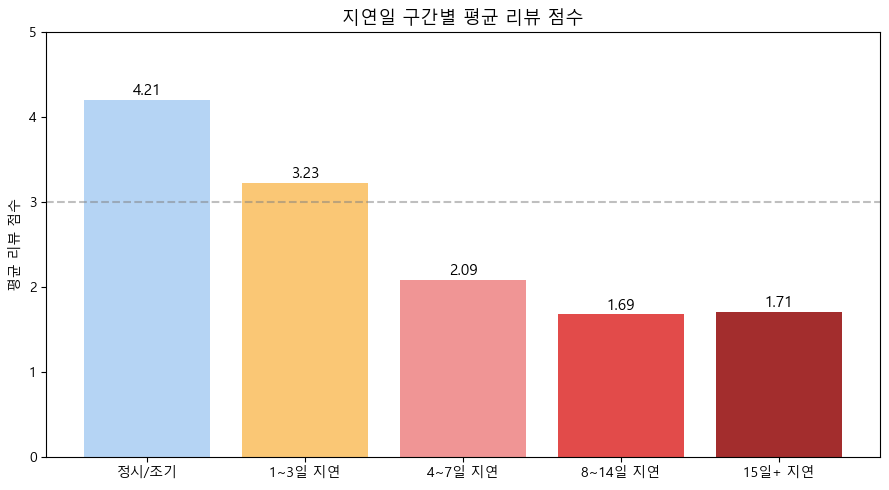

In [11]:
# 지연일 구간별 평균 리뷰
delay_groups = {
    '정시/조기': df[df['days_diff'] <= 0]['review_score_mean'].mean(),
    '1~3일 지연': df[(df['days_diff'] > 0) & (df['days_diff'] <= 3)]['review_score_mean'].mean(),
    '4~7일 지연': df[(df['days_diff'] > 3) & (df['days_diff'] <= 7)]['review_score_mean'].mean(),
    '8~14일 지연': df[(df['days_diff'] > 7) & (df['days_diff'] <= 14)]['review_score_mean'].mean(),
    '15일+ 지연': df[df['days_diff'] > 14]['review_score_mean'].mean(),
}

for k, v in delay_groups.items():
    n = len(df[(df['days_diff'] <= 0)] if k == '정시/조기' else [])
    print(f"{k}: {v:.3f}점")

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#B5D4F4', '#FAC775', '#F09595', '#E24B4A', '#A32D2D']
bars = ax.bar(delay_groups.keys(), delay_groups.values(), color=colors)
ax.set_title('지연일 구간별 평균 리뷰 점수', fontsize=13)
ax.set_ylabel('평균 리뷰 점수')
ax.set_ylim(0, 5)
ax.axhline(y=3, color='gray', linestyle='--', alpha=0.5)

for bar, val in zip(bars, delay_groups.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('delay_review_by_group.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# 3일 이하 지연 주문만 기준으로 시뮬레이션
# 예정일 +1~3일 추가 시 1~3일 지연 그룹이 정시로 전환되는 효과

results3 = []

for extra_days in range(0, 4):  # 0~3일만
    new_estimated = df['order_estimated_delivery_date'] + pd.Timedelta(days=extra_days)
    new_is_late = df['order_delivered_customer_date'] > new_estimated
    
    # 1~3일 지연 그룹에서 전환된 주문
    late_1_3_mask = (df['days_diff'] > 0) & (df['days_diff'] <= 3)
    converted = (late_1_3_mask & (new_is_late == False)).sum()
    
    # 전환된 주문은 조기 도착 평균 리뷰(4.21)로 개선
    total_1_3 = late_1_3_mask.sum()
    remaining_late = total_1_3 - converted
    
    expected_review = (
        (early_review * converted + late_1_3['review_score_mean'].mean() * remaining_late) / total_1_3
    )
    
    results3.append({
        '추가일수': extra_days,
        '전환건수': converted,
        '1~3일지연_예상리뷰': round(expected_review, 3)
    })

results3_df = pd.DataFrame(results3)
print(results3_df.to_string())

   추가일수  전환건수  1~3일지연_예상리뷰
0     0     0        3.231
1     1     0        3.231
2     2   938        3.667
3     3  1541        3.947


In [7]:
# 재구매율 및 매출 손실 회복 시뮬레이션
# 기준: 지연→정시 전환 비율만큼 재구매율 개선된다고 가정
# 정시 첫구매 재구매율 3.15%, 지연 첫구매 재구매율 2.67%

normal_repurchase = 0.0315
late_repurchase = 0.0267
avg_payment = df['payment_value_total'].median()  # 주문당 중앙값 결제액

results2 = []

for extra_days in range(0, 8):
    new_estimated = df['order_estimated_delivery_date'] + pd.Timedelta(days=extra_days)
    new_is_late = df['order_delivered_customer_date'] > new_estimated
    
    # 전환된 고객 수 (지연→정시)
    converted = ((df['is_late'] == True) & (new_is_late == False)).sum()
    
    # 전환된 고객의 재구매율 개선
    # 지연 재구매율 → 정시 재구매율로 전환
    repurchase_gain = converted * (normal_repurchase - late_repurchase)
    
    # 매출 회복 추정
    revenue_recovery = repurchase_gain * avg_payment
    
    results2.append({
        '추가일수': extra_days,
        '전환건수': converted,
        '재구매_증가고객수': round(repurchase_gain, 1),
        '매출회복_BRL': round(revenue_recovery, 0)
    })

results2_df = pd.DataFrame(results2)
print(results2_df.to_string())

   추가일수  전환건수  재구매_증가고객수  매출회복_BRL
0     0     0        0.0       0.0
1     1  1450        7.0     796.0
2     2  2388       11.5    1311.0
3     3  2991       14.4    1642.0
4     4  3560       17.1    1954.0
5     5  4055       19.5    2226.0
6     6  4562       21.9    2504.0
7     7  5014       24.1    2752.0


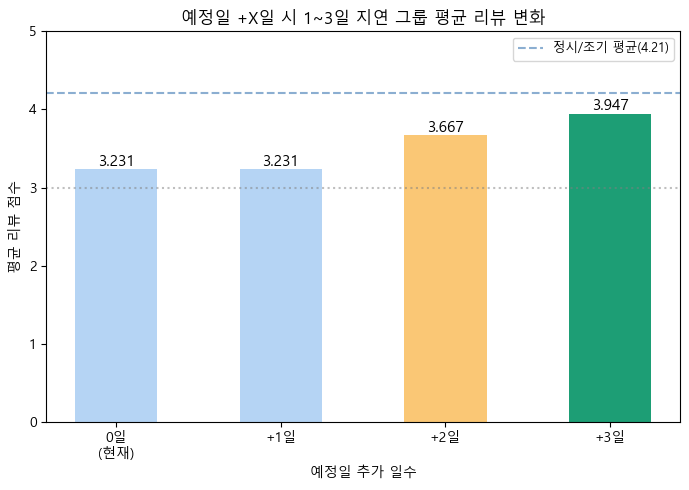

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))

x = [0, 1, 2, 3]
colors = ['#B5D4F4', '#B5D4F4', '#FAC775', '#1D9E75']
values = results3_df['1~3일지연_예상리뷰'].tolist()

bars = ax.bar(x, values, color=colors, width=0.5)
ax.set_title('예정일 +X일 시 1~3일 지연 그룹 평균 리뷰 변화', fontsize=12)
ax.set_xlabel('예정일 추가 일수')
ax.set_ylabel('평균 리뷰 점수')
ax.set_ylim(0, 5)
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(['0일\n(현재)', '+1일', '+2일', '+3일'])
ax.axhline(y=4.21, color='#185FA5', linestyle='--', alpha=0.5, label='정시/조기 평균(4.21)')
ax.axhline(y=3.0, color='gray', linestyle=':', alpha=0.5)
ax.legend(fontsize=9)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.3f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('ab_test_1to3day_review.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
print(f"주문당 중앙값 결제액: R${avg_payment:.2f}")
print(f"주문당 평균 결제액: R${df['payment_value_total'].mean():.2f}")

주문당 중앙값 결제액: R$114.34
주문당 평균 결제액: R$179.47


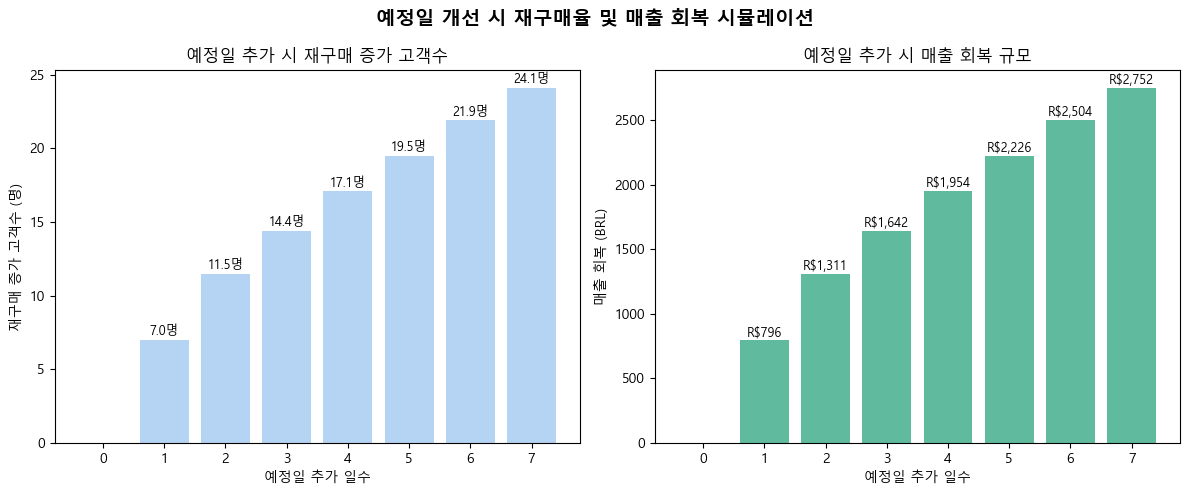

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x = results2_df['추가일수']

# 왼쪽: 재구매 증가 고객수
axes[0].bar(x, results2_df['재구매_증가고객수'], color='#B5D4F4')
axes[0].set_title('예정일 추가 시 재구매 증가 고객수', fontsize=12)
axes[0].set_xlabel('예정일 추가 일수')
axes[0].set_ylabel('재구매 증가 고객수 (명)')
for i, row in results2_df.iterrows():
    if row['재구매_증가고객수'] > 0:
        axes[0].text(row['추가일수'], row['재구매_증가고객수'] + 0.3,
                    f"{row['재구매_증가고객수']}명", ha='center', fontsize=9)

# 오른쪽: 매출 회복
axes[1].bar(x, results2_df['매출회복_BRL'], color='#1D9E75', alpha=0.7)
axes[1].set_title('예정일 추가 시 매출 회복 규모', fontsize=12)
axes[1].set_xlabel('예정일 추가 일수')
axes[1].set_ylabel('매출 회복 (BRL)')
for i, row in results2_df.iterrows():
    if row['매출회복_BRL'] > 0:
        axes[1].text(row['추가일수'], row['매출회복_BRL'] + 30,
                    f"R${row['매출회복_BRL']:,.0f}", ha='center', fontsize=9)

plt.suptitle('예정일 개선 시 재구매율 및 매출 회복 시뮬레이션', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ab_test_repurchase_simulation.png', dpi=150, bbox_inches='tight')
plt.show()